# Training Loop Example

In this notebook, we implement a training loop for a basic transformer model in pyTorch on the tiny shakespeare data set, as a hommage to nanoGPT from Andrej Karpathy's brilliant [Neural Networks: Zero to Hero](https://www.youtube.com/playlist?list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ) series.

## Imports and Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from matplotlib.pylab import plt

In [2]:
from adam import Adam

In [3]:
file_path = "../data/input.txt"

with open(file_path, "r") as f:
    dataset = list(f.read())

## Dataset Preparation

In [4]:
chars = sorted(set(dataset))
ctoi = {c:i for i, c in enumerate(chars)}
itoc = {ctoi[c]:c for c in ctoi.keys()}

In [5]:
encode = lambda s: [ctoi[c] for c in s]
decode = lambda s: "".join([itoc[i] for i in s])

In [6]:
data = encode(dataset)
data_tensor = torch.tensor(data, dtype=torch.long)
data_size = data_tensor.size(dim=0)

In [7]:
split = round(data_size*0.9)
data_train = data_tensor[:split]
data_val = data_tensor[split:]

In [8]:
len_train = data_train.size(dim=0)
len_val = data_val.size(dim=0)

In [9]:
print(f"length of training set: {len_train}")
print(f"length of validation set: {len_val}")

length of training set: 1003855
length of validation set: 111539


In [10]:
batch_size = 64

In [11]:
def get_batch(data: torch.Tensor) -> (torch.Tensor, torch.Tensor):
    batch_indizes = torch.randint(len(data) - block_size - 1, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in batch_indizes])
    y = torch.stack([data[i+1:i+block_size+1] for i in batch_indizes])
    return x, y

## Model Initialization

In [12]:
class Model(nn.Module):

    def __init__(self, block_size: int, vocab_size: int, d_model: int, nhead: int, num_layers: int):
        super().__init__()
        self.block_size = block_size

        self.token_embedding = nn.Embedding(vocab_size, d_model)

        self.positional_embedding = nn.Embedding(block_size, d_model)
        self.register_buffer("causal_mask", torch.triu(torch.ones(block_size, block_size), diagonal=1).bool())

        self.encoding_layer = nn.TransformerEncoderLayer(d_model, nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(self.encoding_layer, num_layers, enable_nested_tensor=False)

        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, inputs: torch.Tensor):
        T = inputs.size(0) if inputs.dim() == 1 else inputs.size(1)

        embeddings = self.token_embedding(inputs)
        pos = torch.arange(T, device=inputs.device)
        pos_embeddings = self.positional_embedding(pos)
        embeddings += pos_embeddings

        mask = self.causal_mask[:T, :T]
        transformer_outputs = self.transformer(embeddings, mask)
        logits = self.lm_head(transformer_outputs)
        return logits

In [13]:
block_size = 128
vocab_size = len(chars)
d_model = 128
nhead = 4
num_layers = 4

## Training Loop (our Adam)

### Initialization and Setup

In [14]:
model = Model(block_size, vocab_size, d_model, nhead, num_layers)
model.train();

In [15]:
params = model.parameters()
optim = Adam(params, lr=0.001)

In [16]:
losses = []

In [17]:
num_iters = 10000

### Actual training loop

In [18]:
for _ in tqdm(range(num_iters)):
    sequence_idx = np.random.randint(0, len_train - block_size - 1)
    x, y = get_batch(data_train)
    
    logits = model(x)
    B, T, C = logits.shape
    logits = logits.view(B*T, C)
    targets = y.view(B*T)
    loss = F.cross_entropy(logits, targets)

    losses.append(loss.item())

    optim.zero_grad()
    loss.backward()
    optim.step()

100%|██████████| 10000/10000 [1:22:31<00:00,  2.02it/s]


Text(0, 0.5, 'Loss')

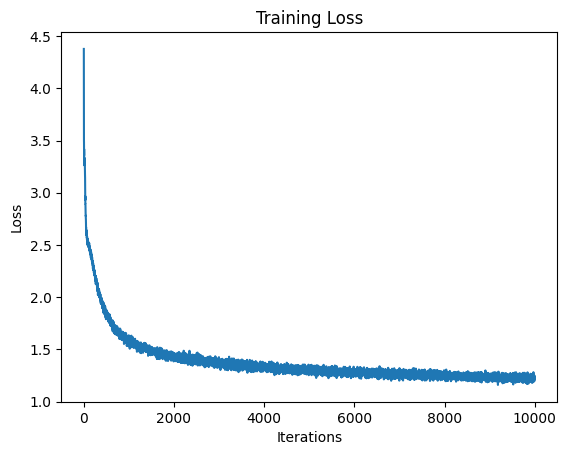

In [19]:
plt.plot(range(1,num_iters + 1), losses)
plt.title("Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")

### Validation

In [20]:
model.eval()

val_losses = []

eval_iters = 500

with torch.no_grad():
    for _ in tqdm(range(eval_iters)):
        sequence_idx = np.random.randint(0, len_val - block_size - 1)
        x, y = get_batch(data_val)
        
        logits = model(x)
        B, T, C = logits.shape
        logits = logits.view(B*T, C)
        targets = y.view(B*T)
        loss = F.cross_entropy(logits, targets)

        val_losses.append(loss.item())

model.train()

val_loss = np.average(val_losses)
print(f"average validation loss with {eval_iters} iterations: {val_loss}")

100%|██████████| 500/500 [00:40<00:00, 12.41it/s]

average validation loss with 500 iterations: 1.4893416283130645


### Sampling

In [21]:
text_len = 2000

text = torch.tensor(encode("To be or not to be"), dtype=torch.long)

for _ in tqdm(range(text_len)):
    context = text[-block_size:]
    logits = model(context)
    next_logits = logits[-1]
    probs = F.softmax(next_logits)
    idx = torch.multinomial(probs, num_samples=1)
    text = torch.cat([text, idx])

text = decode(text.tolist())
print(text)

  0%|          | 0/2000 [00:00<?, ?it/s]/var/folders/xk/wh_dv4fd785263srbm07380m0000gn/T/ipykernel_40232/1031198067.py:9: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(next_logits)
100%|██████████| 2000/2000 [00:12<00:00, 155.42it/s]

To be or not to be losing you; I cannot no more;
but it is in their teeth hus-dorsen'd small is
Of one woman to have this fearful puttied.
Let's ever your great battle; I were brave answer you diston.

KING EDWARD IV:
There was 'tis nothing for king in us.

JOh, O, I doubt, well, he may to match thee?
Did dost thou last, teace the mouse of York is he
I dose the wade thief that alterpaste of reparts
This soul is the varlet, send or tburnes by himself, which I
past or of many have thoughtted of mine
To thought accusion. How now, no, sir, and light;
Where, I hava' him to enside.

Second Pubolian:
Her wits to that fight of in her loss for one is lance.

NUServen:
You have hell go, since no more than a devil gess.

LUCIO:
O, it both, my lord.

ANGELO:
Pray you, poor sir!

Shepherd:
A battle, and unless says
Where live to defaise a dishorit , 'bachert betime
He is attoriors: fear, and if you stand hill?

Now Mayor:
And explitation wash, I aught to him?

LUCIO:
I did you hard marry, again.

F

## Training Loop (torch.optim.Adam)

### Initialization and Setup

In [22]:
model2 = Model(block_size, vocab_size, d_model, nhead, num_layers)
model2.train();

In [23]:
params = model2.parameters()
optim2 = torch.optim.Adam(params, lr=0.001)

In [24]:
losses = []

In [25]:
num_iters = 10000

### Actual training loop

In [26]:
for _ in tqdm(range(num_iters)):
    sequence_idx = np.random.randint(0, len_train - block_size - 1)
    x, y = get_batch(data_train)
    
    logits = model2(x)
    B, T, C = logits.shape
    logits = logits.view(B*T, C)
    targets = y.view(B*T)
    loss = F.cross_entropy(logits, targets)

    losses.append(loss.item())

    optim2.zero_grad()
    loss.backward()
    optim2.step()

100%|██████████| 10000/10000 [1:21:56<00:00,  2.03it/s]


Text(0, 0.5, 'Loss')

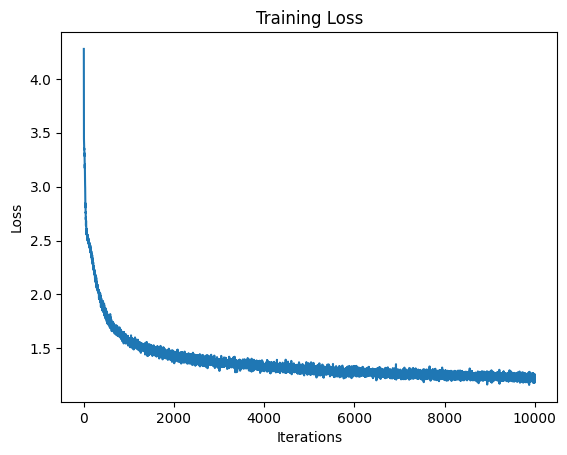

In [27]:
plt.plot(range(1,num_iters + 1), losses)
plt.title("Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")

### Validation

In [28]:
model2.eval()

val_losses = []

eval_iters = 500

with torch.no_grad():
    for _ in tqdm(range(eval_iters)):
        sequence_idx = np.random.randint(0, len_val - block_size - 1)
        x, y = get_batch(data_val)
        
        logits = model2(x)
        B, T, C = logits.shape
        logits = logits.view(B*T, C)
        targets = y.view(B*T)
        loss = F.cross_entropy(logits, targets)

        val_losses.append(loss.item())

model2.train()

val_loss = np.average(val_losses)
print(f"average validation loss with {eval_iters} iterations: {val_loss}")

100%|██████████| 500/500 [00:38<00:00, 12.89it/s]

average validation loss with 500 iterations: 1.5047186512947082


### Sampling

In [29]:
text_len = 2000

text2 = torch.tensor(encode("To be or not to be"), dtype=torch.long)

for _ in tqdm(range(text_len)):
    context = text2[-block_size:]
    logits = model(context)
    next_logits = logits[-1]
    probs = F.softmax(next_logits)
    idx = torch.multinomial(probs, num_samples=1)
    text2 = torch.cat([text2, idx])

text2 = decode(text2.tolist())
print(text2)

  0%|          | 0/2000 [00:00<?, ?it/s]/var/folders/xk/wh_dv4fd785263srbm07380m0000gn/T/ipykernel_40232/1470206392.py:9: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(next_logits)
100%|██████████| 2000/2000 [00:12<00:00, 163.01it/s]

To be or not to be, sir; my letters, all standarest,
had but with minackle wars sometistile her;
Sacrifvy her own again dick unknown, or else
Thenooking; I am hung grave for him, not little
Endhersicing new that we may learn indimed good wounded.
Saint Peter, let me light: go we legs, you like deep.

CORIOLANUS:
Yes, art as his pose: she would he wrought that special
you to the's desway of balred by outrages, and
In nothing but called?

VOLUMNIA:
Hath art so; youd presence, madam is at
A sweet dolour and melass-day no men's peasant, and yet needs hear me,
Come, bring it for London.

HASTINGS:
Not, good measured, induce, since it not his hearts
And to this pent at once and once yourselved.

GLOUCESTER:
Find his eyes on England approach, and vicks each
moneye.

LARTIUS:

MENCE:
Mountagues
His love more.

DUKE OF YORK:
If-too say your dishings to down away.
3 KING HENRY VI:
'Tis sweet Mayor, soone take her thence; my lord,
Nor except without that thonough that thou dost sin
And sulph, and

## Conclusions

A model trained using our implementation of the Adam optimizer is indistinguishable from one trained using the official torch.optim.Adam optimizer.
This shows that a simple implementation using the suggested optimal order of calculations from the original paper is sufficient to achieve equivalent effectiveness to that of the industry standard, although it does not offer some of the customization options of the official version.